
# 0. IMPORTS E CONFIGURAÇÃO GLOBAL


In [22]:
import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, cross_val_predict,KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

In [23]:
# Configurações
RANDOM_STATE = 42
TEST_SIZE = 0.2
FILE_PATH = "./content/dados_jamovi.xlsx"
TARGET_COL = "Velocity (mean) [µm/s]"

# Parametros do modelo
GBR_PARAMS = dict(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Constantes físicas
RHO_F = 1000.0  # Fluid density (kg/m³)
MU = 0.001      # Dynamic viscosity (Pa·s)
G = 9.81        # Gravity (m/s²)
RHO_P = 2600.0  # Particle density (kg/m³)


# FUNCÕES UTILITARIAS 

In [51]:
def load_data(file_path, target_col):
    """
    Load data from Excel and separate into features and target.

    Parameters
    ----------
    file_path : str
        Path to Excel file.
    target_col : str
        Name of the target column.

    Returns
    -------
    tuple
        (data, X, y) where:
        - data: full DataFrame
        - X: feature DataFrame (numeric columns only, excluding target)
        - y: target Series
    """
    data = pd.read_excel(file_path)

    if target_col not in data.columns:
        raise ValueError(f"Target not found: {target_col}")

    numeric_data = data.select_dtypes(include=[np.number])
    
    X = numeric_data.drop(columns=[target_col])
    y = numeric_data[target_col]

    return data, X, y



In [82]:
def handle_missing_values(
    X, y,
    strategy="impute",
    impute_method="mean",
    imputer=None,
    verbose=True
):
    """
    Handle missing values in features and target.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix with possible missing values.
    y : pandas.Series
        Target variable aligned with ``X``.
    strategy : {"impute", "drop"}, default="impute"
        Strategy for handling missing values:
        - "drop": remove rows with missing values in ``X`` or ``y``.
        - "impute": impute missing values in ``X`` using ``SimpleImputer``.
    impute_method : str, default="mean"
        Imputation strategy used when ``strategy="impute"``.
    imputer : sklearn.impute.SimpleImputer or None, default=None
        Pre-fitted imputer. If None, a new imputer is fitted on ``X``.
    verbose : bool, default=True
        Whether to print a summary of the operation.

    Returns
    -------
    X_clean : pandas.DataFrame
        Feature matrix after dropping or imputing missing values.
    y_clean : pandas.Series
        Target variable after dropping rows or unchanged when imputing.
    imputer : sklearn.impute.SimpleImputer or None
        Fitted imputer when ``strategy="impute"``, otherwise None.

    Raises
    ------
    ValueError
        If ``strategy`` is invalid or if ``y`` contains missing values when
        using ``strategy="impute"``.
    """

    if strategy == "drop":
        mask = X.notna().all(axis=1) & y.notna()
        X_clean = X.loc[mask].copy()
        y_clean = y.loc[mask].copy()

        if verbose:
            print(f"Dropped {len(X) - len(X_clean)} rows with missing values")

        return X_clean, y_clean, None

    elif strategy == "impute":
        if imputer is None:
            imputer = SimpleImputer(strategy=impute_method)
            X_clean = pd.DataFrame(
                imputer.fit_transform(X),
                columns=X.columns,
                index=X.index
            )
        else:
            X_clean = pd.DataFrame(
                imputer.transform(X),
                columns=X.columns,
                index=X.index
            )

        if y.isna().any():
            raise ValueError("Target y contains NaNs. Handle before fitting.")

        if verbose:
            print(f"Imputed missing values using strategy: {impute_method}")

        return X_clean, y.copy(), imputer

    else:
        raise ValueError("strategy must be 'drop' or 'impute'")


In [52]:

def handle_missing_values(X, y, strategy="impute", impute_method="mean"):
    """
    Handle missing values in features and target.

    Parameters
    ----------
    X : DataFrame
        Feature matrix.
    y : Series
        Target variable.
    strategy : {"impute", "drop"}
        Strategy to handle missing values.
        - "impute": Fill missing values using SimpleImputer
        - "drop": Remove rows with any missing values
    impute_method : str
        Strategy for SimpleImputer (e.g., "mean", "median", "most_frequent").
        Only used when strategy="impute".

    Returns
    -------
    tuple
        (X_clean, y_clean) - cleaned feature matrix and target
    """
    if strategy == "drop":
        mask = X.notna().all(axis=1) & y.notna()
        X_clean = X.loc[mask].copy()
        y_clean = y.loc[mask].copy()
        
        print(f"Dropped {len(X) - len(X_clean)} rows with missing values")

    elif strategy == "impute":
        imputer = SimpleImputer(strategy=impute_method)
        X_imputed = imputer.fit_transform(X)
        X_clean = pd.DataFrame(
            X_imputed,
            columns=X.columns,
            index=X.index
        )
        y_clean = y.copy()
        
        print(f"Imputed missing values using strategy: {impute_method}")

    else:
        raise ValueError(
            f"Invalid strategy '{strategy}'. Must be 'impute' or 'drop'"
        )

    return X_clean, y_clean

In [53]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [54]:
def gbr_train_predict(X_train, y_train, X_test, params):
    model = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    return model.predict(X_test), model 

In [55]:
def bootstrap_mae(
    y_true,
    y_pred,
    n_boot=100,
    random_state=42
):
    """
    Bootstrap do MAE a partir de pares (y_true, y_pred).

    Parâmetros
    ----------
    y_true : array-like
        Valores observados.
    y_pred : array-like
        Valores preditos pelo modelo (fixos).
    n_boot : int
        Número de reamostragens bootstrap.
    random_state : int
        Seed para reprodutibilidade.

    Retorna
    -------
    dict com:
        mae_boot : np.ndarray
        mean_mae : float
        std_mae  : float
        ci_low   : float (IC 2.5%)
        ci_high  : float (IC 97.5%)
    """
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    n = len(y_true)
    mae_boot = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)  # amostragem com reposição
        mae_boot[i] = mean_absolute_error(
            y_true[idx],
            y_pred[idx]
        )

    mean_mae = mae_boot.mean()
    std_mae  = mae_boot.std(ddof=1)
    ci_low, ci_high = np.percentile(mae_boot, [2.5, 97.5])

    return {
        "mae_boot": mae_boot,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


# DATA LOADING AND PREPROCESSING

In [56]:
# Load data
data, X, y = load_data(FILE_PATH, TARGET_COL)

# Handle missing values
X, y = handle_missing_values(X, y, strategy="impute", impute_method="mean")


Imputed missing values using strategy: mean


# FEATURE ENGINEERING

In [57]:


class PhysicsFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Scikit-learn transformer for computing physics-based features from particle data.
    
    Parameters:
    -----------
    target_col : str
        Name of velocity column in the original dataframe
    use_diameter : bool, default=True
        If True, use diameter formula (new); if False, use radius directly (old)
    rho_f : float, default=1000.0
        Fluid density (kg/m³)
    rho_p : float, default=2500.0
        Particle density (kg/m³)
    mu : float, default=0.001
        Dynamic viscosity (Pa·s)
    g : float, default=9.81
        Gravitational acceleration (m/s²)
    
    Attributes:
    -----------
    feature_names_ : list
        Names of the generated physics features
    """
    
    def __init__(self, use_diameter=True, 
                 rho_f=RHO_F, rho_p=RHO_P, mu=MU, g=G):
        self.use_diameter = use_diameter
        self.rho_f = rho_f
        self.rho_p = rho_p
        self.mu = mu
        self.g = g
        
    def fit(self, X, y):
        """        
        Parameters:
        -----------
        X : DataFrame
            Input data (not used, but stored for reference)
        y : array-like
            Target values
            
        Returns:
        --------
        Store target variable explicitly.
        """

        if y is None:
            raise ValueError(
                "PhysicsFeatureEngineerWithTarget requires `y` in fit(). "
                "This transformer intentionally uses the target variable."
            )

        # Store y as pandas Series aligned with X
        self.y_ = pd.Series(y, index=X.index, name="velocity")

        self.feature_names_ = [
            "PFE_Re",
            "PFE_Cd",
            "PFE_Fd",
            "PFE_r2"
        ]

        return self
    
    def transform(self, X):
        """
        Transform the input data by adding physics features.
        
        Transform X using stored target values.

        Parameters:
        -----------
        X : DataFrame
            Input data with particle measurements
            
        Returns:
        --------
        DataFrame with original features plus physics features
        """

        if not hasattr(self, "y_"):
            raise RuntimeError("Transformer must be fitted before calling transform().")

        # Compute physics features
        physics_features = self._compute_physics_features(X)
        
    
        return pd.concat([X, physics_features], axis=1)

    
    def fit_transform(self, X, y, **fit_params):
        """
        Fit and transform in one step.
        
        Parameters:
        -----------
        X : DataFrame
            Input data with particle measurements
        y : array-like, optional
            Target values (not used)
            
        Returns:
        --------
        DataFrame with original features plus physics features
        """
    
        return self.fit(X, y).transform(X)
    
    def _compute_physics_features(self, df):
        """
        Internal method to compute physics-based features.
        
        Parameters:
        -----------
        df : DataFrame
            Input data with particle measurements
            
        Returns:
        --------
        DataFrame with physics features
        """
        # Extract and convert units
        A = df["Area (mean) [µm²]"] * 1e-12
        r = df["Radius (max) (mean) [µm]"] * 1e-6
        v = self.y_ * 1e-6  # µm/s → m/s (INTENTIONAL LEAKAGE)
        
        # Calculate characteristic length
        if self.use_diameter:
            d = 2.0 * np.sqrt(A / np.pi)
            characteristic_length = d
        else:
            characteristic_length = r
        
        # Reynolds number
        Re = (self.rho_f * v * characteristic_length) / self.mu
        Re = Re.where(Re > 0).replace([np.inf, -np.inf], np.nan)
        
        # Drag coefficient (Stokes regime)
        Cd = 24.0 / Re
        
        # Drag force
        Fd = 0.5 * self.rho_f * Cd * A * v**2
        
        # Radius squared
        r2 = r**2
        
        return pd.DataFrame({
            "PFE_Re": Re,
            "PFE_Cd": Cd,
            "PFE_Fd": Fd,
            "PFE_r2": r2
        }, index=df.index)
    
    def get_feature_names_out(self, input_features=None):
        """
        Get output feature names for transformation.
        
        Parameters:
        -----------
        input_features : array-like of str, optional
            Input feature names
            
        Returns:
        --------
        array of str
            Output feature names
        """
        if input_features is None:
            return np.array(self.feature_names_)
        else:
            return np.concatenate([input_features, self.feature_names_])

# EXPERIMENTO 1 - CROSS VALIDATION

## Configuracao experimental


In [58]:
# Cross-validation
model_cv = GradientBoostingRegressor(**GBR_PARAMS)
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Modelo 1 - Tradicional GBR (Baseline)

In [59]:
cv_pred_a = cross_val_predict(model_cv, X, y, cv=kfold)


In [60]:
# Create evaluation dataframes
df_cv_trad = pd.DataFrame({
    "y_pred": cv_pred_a,
    "y_true": y.reset_index(drop=True),
    "residuals": y.reset_index(drop=True) - cv_pred_a,
    "model": "Traditional"
})

## Modelo 2 - PFE - GBR

In [61]:
# Create the transformer
pfe = PhysicsFeatureEngineer(
    use_diameter=False,
    rho_f=RHO_F,  # Use your constants
    mu=MU,
    g=G
)

# Fit transform - Physics Feature Engineering
X_pfe = pfe.fit_transform(X,y)

In [62]:
cv_pred_b = cross_val_predict(model_cv, X_pfe, y, cv=kfold)

In [63]:

# Create evaluation dataframes
df_cv_pfe = pd.DataFrame({
    "y_pred": cv_pred_b,
    "y_true": y.reset_index(drop=True),
    "residuals": y.reset_index(drop=True) - cv_pred_b,
    "model": "PFE"
})


## Comparacao de resultados

In [64]:
# Combinando os dataframes de avaliacao 
df_cv = pd.concat([df_cv_trad, df_cv_pfe]).reset_index(drop=True)


In [65]:
# Evaluate CV results
cv_results = pd.DataFrame.from_dict({
    "Traditional GBR (CV)": evaluate(df_cv_trad['y_true'], df_cv_trad['y_pred']),
    "PFE-GBR (CV)": evaluate(df_cv_pfe['y_true'], df_cv_pfe['y_pred'])
}, orient="index")

print(cv_results)

                             MAE        RMSE        R2
Traditional GBR (CV)  234.314568  397.489626  0.886877
PFE-GBR (CV)          135.693109  262.877990  0.950523


## Real vs Predicted Velocity 

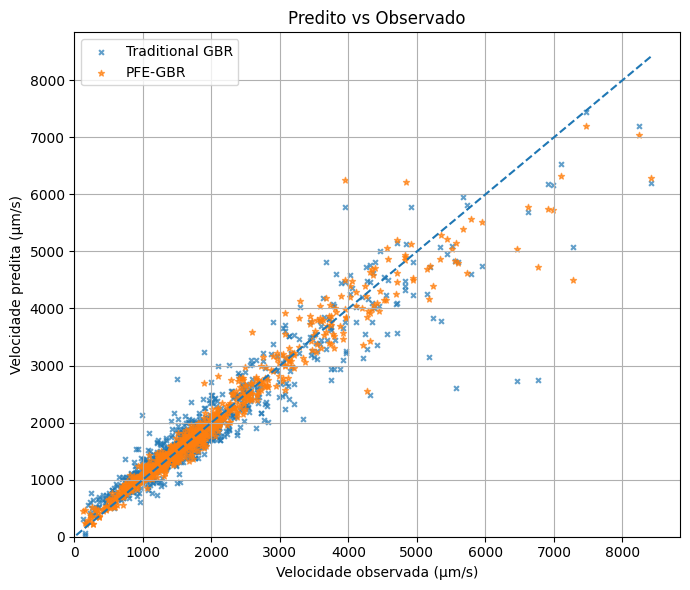

In [66]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_cv_trad, "Traditional GBR", "x", 12),
    (df_cv_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_true"],
        df_["y_pred"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

lims = [
    min(df_cv["y_true"].min(), df_cv["y_pred"].min()),
    max(df_cv["y_true"].max(), df_cv["y_pred"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])
plt.ylim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Error Analysis


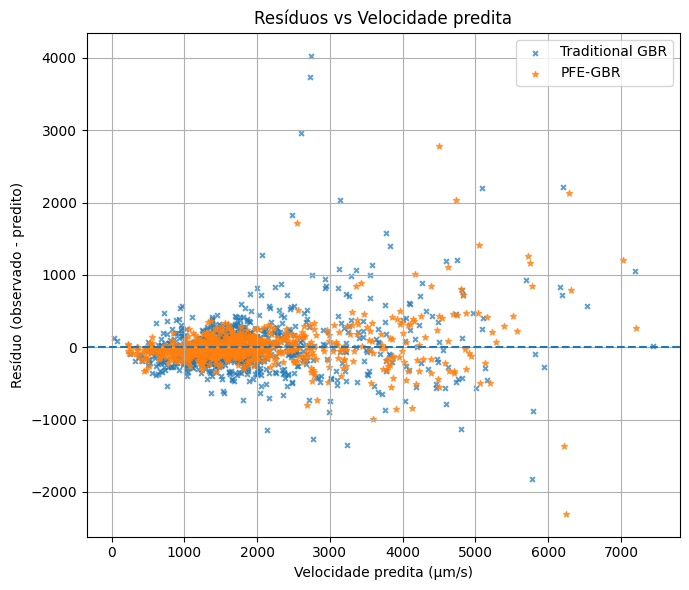

In [67]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_cv_trad, "Traditional GBR", "x", 12),
    (df_cv_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_pred"],
        df_["residuals"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

plt.axhline(0, linestyle="--")

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado - predito)")
plt.title("Resíduos vs Velocidade predita")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# EXPERIMENTO 2 - VALIDACAO HOLDOUT

## Split train and test set

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

## Modelo 1 - Traditional GBR (Baseline)


### Train and predict 

In [70]:
y_pred_trad, trad_gbr_model = gbr_train_predict(X_train, y_train, X_test, GBR_PARAMS)

df_eval_trad = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_trad,
    "residuals": y_test - y_pred_trad,
    "experiment": "Traditional GBR"
})



## Modelo 2 - PFE - GBR


### Feature Engineering - Phisical features

In [71]:
# Create the transformer
pfe = PhysicsFeatureEngineer(
    use_diameter=False,
    rho_f=RHO_F,  # Use your constants
    mu=MU,
    g=G
)

# Fit transform - Physics Feature Engineering
X_train_pfe = pfe.fit_transform(X_train,y)
X_test_pfe = pfe.fit_transform(X_test,y)

### Training and model

In [72]:
y_pred_pfe, pfe_gbr_model = gbr_train_predict(X_train_pfe, y_train, X_test_pfe, GBR_PARAMS)

df_eval_pfe = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_pfe,
    "residuals": y_test - y_pred_pfe,
    "experiment": "PFE-GBR"
})


## Comparação dos resultados (conjunto de teste)

In [73]:
results = pd.DataFrame.from_dict({
    "Traditional GBR": evaluate(y_test, y_pred_trad),
    "PFE-GBR": evaluate(y_test, y_pred_pfe)
}, orient="index")

results

,MAE,RMSE,R2
Traditional GBR,232.035470,371.830841,0.916006
PFE-GBR,143.816686,311.426022,0.941079


## Real vs Predicted Velocity 

In [75]:
df_eval = pd.concat([df_eval_trad, df_eval_pfe], axis=0).copy()


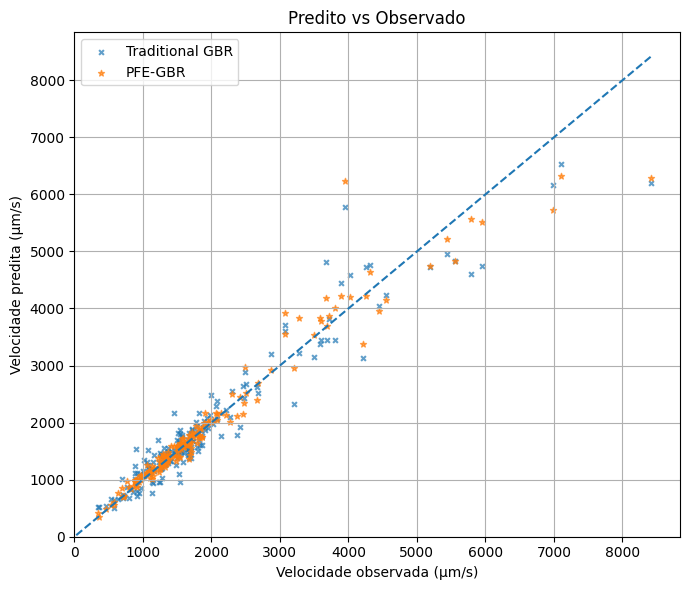

In [76]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_eval_trad, "Traditional GBR", "x", 12),
    (df_eval_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_true"],
        df_["y_pred"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

lims = [
    min(df_cv["y_true"].min(), df_cv["y_pred"].min()),
    max(df_cv["y_true"].max(), df_cv["y_pred"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])
plt.ylim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Error Analysis


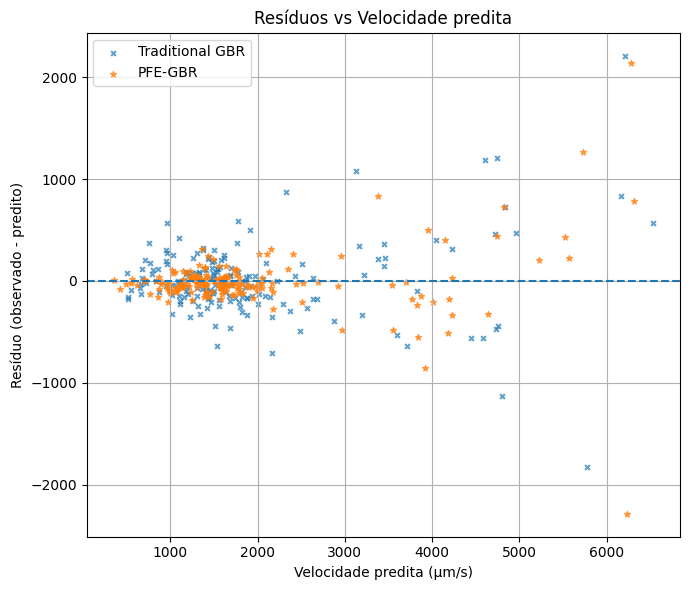

In [77]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_eval_trad, "Traditional GBR", "x", 12),
    (df_eval_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_pred"],
        df_["residuals"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

plt.axhline(0, linestyle="--")

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado - predito)")
plt.title("Resíduos vs Velocidade predita")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Model Interpretability - SHAP Values

##### Observacao 

Mesmo o codigo do professor apresenta resultados de shap diferentes do artigo. as tendencias sao similares, mas nao da pra falar que sao a mesma coisa

## shap.TreeExplainer

### Tradicional GBR

In [ ]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.TreeExplainer(trad_gbr_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


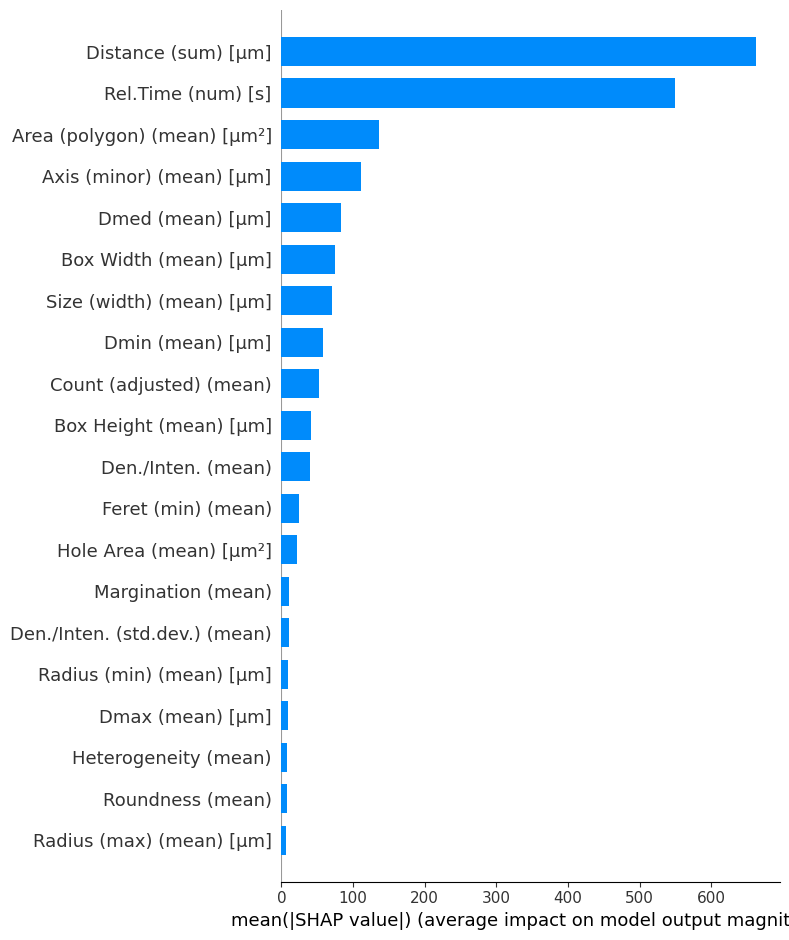

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

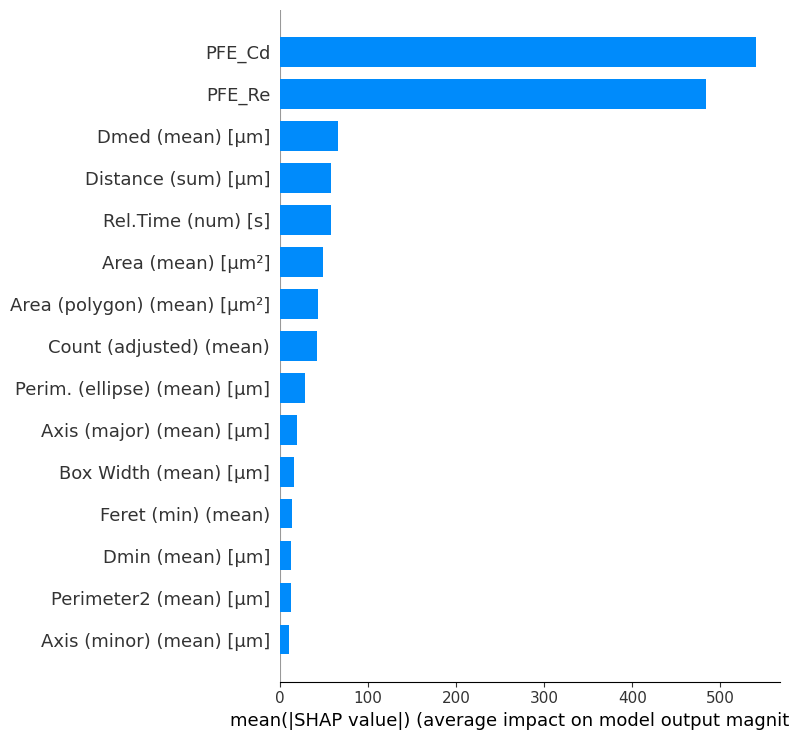

In [ ]:
explainer = shap.TreeExplainer(
    pfe_gbr_model
)

shap_values = explainer.shap_values(X_test_pfe)

shap.summary_plot(
    shap_values,
    X_test_pfe,
    plot_type="bar",
    max_display=15
)

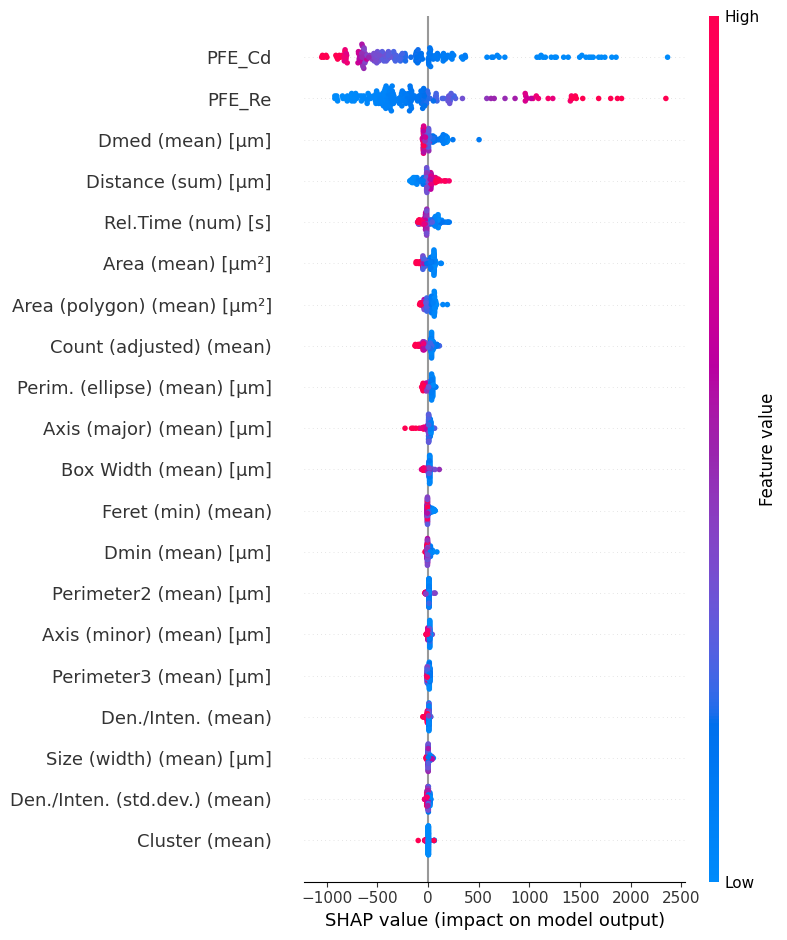

In [ ]:
# PFE - GBR
explainer = shap.TreeExplainer(pfe_gbr_model)
shap_values_pfe = explainer.shap_values(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe, show=False)


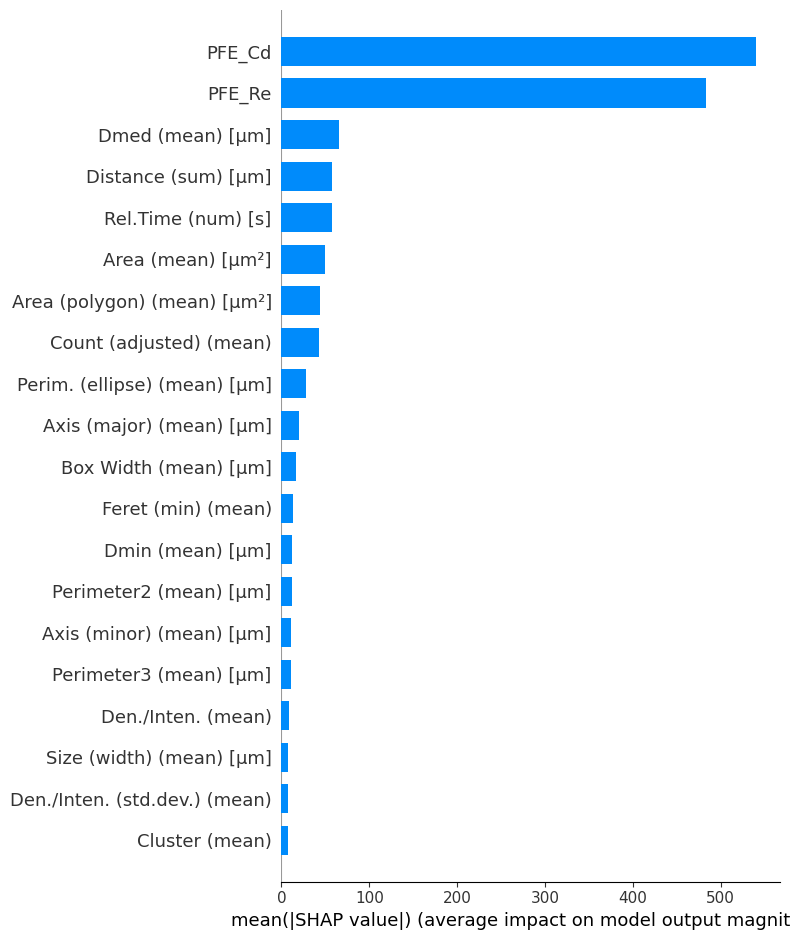

In [ ]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

# 6. Bootstrap analysis


1. LE OS DADOS E SEPARA X E Y 
2. PhysicsFeatureEngineer ANTIGA (SEM O DIAMETRO)
3. IMPUTE MISSING VALUES - MEAN
4. TREINA MODELO 
5. CROSS VALIDATION 


In [79]:
# Load data
data_, X_, y_ = load_data(FILE_PATH, TARGET_COL)

In [101]:
# Create the transformer
pfe_ = PhysicsFeatureEngineer(
    use_diameter=False,
    rho_f=RHO_F,  # Use your constants
    mu=MU,
    g=G
)

# Fit transform - Physics Feature Engineering
X_pfe_ = pfe_.fit_transform(X_,y_)

In [104]:
# Handle missing values
X_pfe_, y_, imputer = handle_missing_values(
    X_pfe_,
    y_,
    strategy="impute",
    impute_method="mean",
)

Imputed missing values using strategy: mean


In [105]:
# Cross-validation
pfe_model_cv_ = GradientBoostingRegressor(**GBR_PARAMS)
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [106]:
cv_pred_ = cross_val_predict(pfe_model_cv_, X_pfe_, y_, cv=kfold)


In [109]:
# Calculate Metrics for Cross-Validation
cv_mae_ = mean_absolute_error(y, cv_pred_)
cv_rmse_ = np.sqrt(mean_squared_error(y, cv_pred_))
cv_r2_ = r2_score(y, cv_pred_)
# Results
print("5-Fold Cross-Validation Metrics:")
print(f"MAE: {cv_mae_}")
print(f"RMSE: {cv_rmse_}")
print(f"R^2: {cv_r2_}")

5-Fold Cross-Validation Metrics:
MAE: 135.6931086547426
RMSE: 262.877990104701
R^2: 0.950522537909287


In [107]:
bootstrap_results = bootstrap_mae(
    y_true=y_,
    y_pred=cv_pred_,
    n_boot=100,
    random_state=42
)

print("Bootstrap MAE (PFE-GBR)")
print(f"Média: {bootstrap_results['mean_mae']:.2f} µm/s")
print(f"DP:    {bootstrap_results['std_mae']:.2f} µm/s")
print(
    f"IC 95%: "
    f"[{bootstrap_results['ci_low']:.2f}, "
    f"{bootstrap_results['ci_high']:.2f}] µm/s"
)

Bootstrap MAE (PFE-GBR)
Média: 135.73 µm/s
DP:    7.47 µm/s
IC 95%: [123.53, 150.44] µm/s


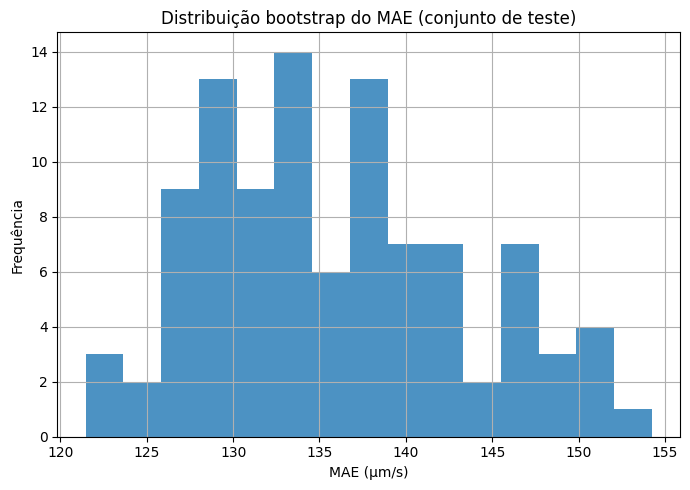

In [108]:
plt.figure(figsize=(7, 5))

plt.hist(
    bootstrap_results["mae_boot"],
    bins=15,
    alpha=0.8
)

plt.xlabel("MAE (µm/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap do MAE (conjunto de teste)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Robustness Analysis - Noise Injection

## 7.1. Performance Degradation Under Noise

# 8. Error Analysis by Morphological Class